In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load data from exploration notebook
DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Try to load CICIDS2017 or use sample data
def load_or_create_data(n_samples=20000):
    """Load dataset or create sample data."""
    csv_files = list((DATA_DIR / 'datasets' / 'CICIDS2017').glob('*.csv'))
    
    if csv_files:
        print(f"Loading {csv_files[0].name}...")
        df = pd.read_csv(csv_files[0], nrows=n_samples)
        return df
    
    # Create sample data
    print("Creating sample data for demonstration...")
    np.random.seed(42)
    
    labels = ['BENIGN'] * int(n_samples * 0.7) + \
             ['DoS Hulk'] * int(n_samples * 0.1) + \
             ['PortScan'] * int(n_samples * 0.08) + \
             ['DDoS'] * int(n_samples * 0.05) + \
             ['Bot'] * int(n_samples * 0.04) + \
             ['Brute Force'] * int(n_samples * 0.03)
    
    n = len(labels)
    
    data = {
        'Flow Duration': np.abs(np.random.exponential(1000000, n)),
        'Total Fwd Packets': np.random.poisson(10, n),
        'Total Backward Packets': np.random.poisson(8, n),
        'Total Length of Fwd Packets': np.abs(np.random.exponential(500, n)),
        'Total Length of Bwd Packets': np.abs(np.random.exponential(400, n)),
        'Fwd Packet Length Max': np.random.randint(0, 1500, n),
        'Fwd Packet Length Min': np.random.randint(0, 100, n),
        'Fwd Packet Length Mean': np.abs(np.random.exponential(200, n)),
        'Fwd Packet Length Std': np.abs(np.random.exponential(100, n)),
        'Bwd Packet Length Max': np.random.randint(0, 1500, n),
        'Bwd Packet Length Min': np.random.randint(0, 100, n),
        'Bwd Packet Length Mean': np.abs(np.random.exponential(180, n)),
        'Bwd Packet Length Std': np.abs(np.random.exponential(90, n)),
        'Flow Bytes/s': np.abs(np.random.exponential(10000, n)),
        'Flow Packets/s': np.abs(np.random.exponential(100, n)),
        'Flow IAT Mean': np.abs(np.random.exponential(50000, n)),
        'Flow IAT Std': np.abs(np.random.exponential(30000, n)),
        'Flow IAT Max': np.abs(np.random.exponential(100000, n)),
        'Flow IAT Min': np.abs(np.random.exponential(1000, n)),
        'Fwd IAT Total': np.abs(np.random.exponential(500000, n)),
        'Fwd IAT Mean': np.abs(np.random.exponential(50000, n)),
        'Fwd IAT Std': np.abs(np.random.exponential(30000, n)),
        'Bwd IAT Total': np.abs(np.random.exponential(400000, n)),
        'Bwd IAT Mean': np.abs(np.random.exponential(40000, n)),
        'Bwd IAT Std': np.abs(np.random.exponential(25000, n)),
        'Fwd PSH Flags': np.random.binomial(5, 0.3, n),
        'Bwd PSH Flags': np.random.binomial(3, 0.2, n),
        'Fwd Header Length': np.random.randint(20, 100, n),
        'Bwd Header Length': np.random.randint(20, 80, n),
        'Fwd Packets/s': np.abs(np.random.exponential(50, n)),
        'Bwd Packets/s': np.abs(np.random.exponential(40, n)),
        'Min Packet Length': np.random.randint(0, 100, n),
        'Max Packet Length': np.random.randint(100, 1500, n),
        'Packet Length Mean': np.abs(np.random.exponential(150, n)),
        'Packet Length Std': np.abs(np.random.exponential(80, n)),
        'Packet Length Variance': np.abs(np.random.exponential(5000, n)),
        'SYN Flag Count': np.random.binomial(3, 0.4, n),
        'ACK Flag Count': np.random.binomial(10, 0.6, n),
        'FIN Flag Count': np.random.binomial(2, 0.3, n),
        'RST Flag Count': np.random.binomial(1, 0.1, n),
        'PSH Flag Count': np.random.binomial(3, 0.3, n),
        'URG Flag Count': np.random.binomial(1, 0.05, n),
        'Down/Up Ratio': np.random.uniform(0, 5, n),
        'Average Packet Size': np.abs(np.random.exponential(200, n)),
        'Init_Win_bytes_forward': np.random.randint(0, 65535, n),
        'Init_Win_bytes_backward': np.random.randint(0, 65535, n),
        'Destination Port': np.random.choice([80, 443, 22, 21, 8080, 3389, 53], n),
        'Protocol': np.random.choice([6, 17, 1], n, p=[0.7, 0.25, 0.05]),
        'Label': labels
    }
    
    return pd.DataFrame(data)

df = load_or_create_data()
print(f"\nLoaded {len(df)} samples with {len(df.columns)} features")

Creating sample data for demonstration...

Loaded 20000 samples with 49 features


In [3]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes.value_counts())

df.head()

Dataset shape: (20000, 49)

Column types:
float64    26
int32      20
int64       2
str         1
Name: count, dtype: int64


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,RST Flag Count,PSH Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Init_Win_bytes_forward,Init_Win_bytes_backward,Destination Port,Protocol,Label
0,4.692681e+05,12,9,638.053163,422.613044,875,92,361.727445,5.126143,546,...,0,3,1,0.974228,27.101755,6193,23043,21,6,BENIGN
1,3.010121e+06,8,9,468.270648,942.986600,694,8,8.989829,155.258287,602,...,0,2,0,0.554010,167.757739,1292,23500,80,17,BENIGN
2,1.316746e+06,10,8,782.243058,4.783850,102,48,63.624621,22.946199,80,...,0,1,0,4.374275,54.578978,60332,47136,80,6,BENIGN
3,9.129426e+05,18,8,105.545712,1499.898436,655,99,32.253611,64.812196,91,...,1,0,0,4.439941,301.651015,5340,57357,8080,6,BENIGN
4,1.696249e+05,12,4,344.698526,213.502177,85,54,38.706390,183.273785,907,...,0,2,0,1.738585,208.261970,34629,53063,80,6,BENIGN


## 2. Data Cleaning

In [4]:
# Clean column names
df.columns = df.columns.str.strip()

# Find label column
label_col = 'Label' if 'Label' in df.columns else 'label'
print(f"Label column: {label_col}")

# Separate features and target
X = df.drop(columns=[label_col])
y = df[label_col]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Label column: Label
Features: (20000, 48)
Target: (20000,)


In [5]:
# Handle missing values
print("Missing values before cleaning:")
missing_before = X.isnull().sum().sum()
print(f"  Total: {missing_before}")

# Fill missing with median for numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

print(f"\nMissing values after cleaning: {X.isnull().sum().sum()}")

Missing values before cleaning:
  Total: 0

Missing values after cleaning: 0


In [6]:
# Handle infinite values
print("Infinite values before cleaning:")
inf_count = np.isinf(X[numeric_cols]).sum().sum()
print(f"  Total: {inf_count}")

# Replace infinites with large values
X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan)
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

print(f"\nInfinite values after cleaning: {np.isinf(X[numeric_cols]).sum().sum()}")

Infinite values before cleaning:
  Total: 0

Infinite values after cleaning: 0


In [7]:
# Remove constant features
print("\nRemoving constant features...")
variance_selector = VarianceThreshold(threshold=0)
variance_selector.fit(X[numeric_cols])

constant_features = numeric_cols[~variance_selector.get_support()].tolist()
print(f"Constant features found: {len(constant_features)}")
if constant_features:
    print(f"  {constant_features}")
    X = X.drop(columns=constant_features)

print(f"\nFeatures after removing constants: {X.shape[1]}")


Removing constant features...
Constant features found: 0

Features after removing constants: 48


## 3. Feature Selection

In [8]:
# Encode labels for feature selection
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded values:", np.unique(y_encoded))

Classes: ['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS Hulk' 'PortScan']
Encoded values: [0 1 2 3 4 5]


In [9]:
# Feature importance using Random Forest
print("Calculating feature importance with Random Forest...")

# Get numeric features only
X_numeric = X.select_dtypes(include=[np.number])

# Quick RF for feature importance
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_numeric, y_encoded)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X_numeric.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features:")
print(feature_importance.head(20).to_string(index=False))

Calculating feature importance with Random Forest...

Top 20 Important Features:
                    feature  importance
              Down/Up Ratio    0.037821
              Flow Duration    0.032879
              Flow IAT Mean    0.032017
               Flow IAT Max    0.031550
              Bwd Packets/s    0.031051
                Fwd IAT Std    0.029657
Total Length of Bwd Packets    0.029529
     Bwd Packet Length Mean    0.028891
              Fwd Packets/s    0.028363
              Bwd IAT Total    0.028223
        Average Packet Size    0.027982
              Fwd IAT Total    0.027583
    Init_Win_bytes_backward    0.026967
Total Length of Fwd Packets    0.026945
               Flow Bytes/s    0.026907
               Flow IAT Std    0.025513
               Fwd IAT Mean    0.024862
      Bwd Packet Length Std    0.024393
      Fwd Packet Length Max    0.024227
               Bwd IAT Mean    0.024042


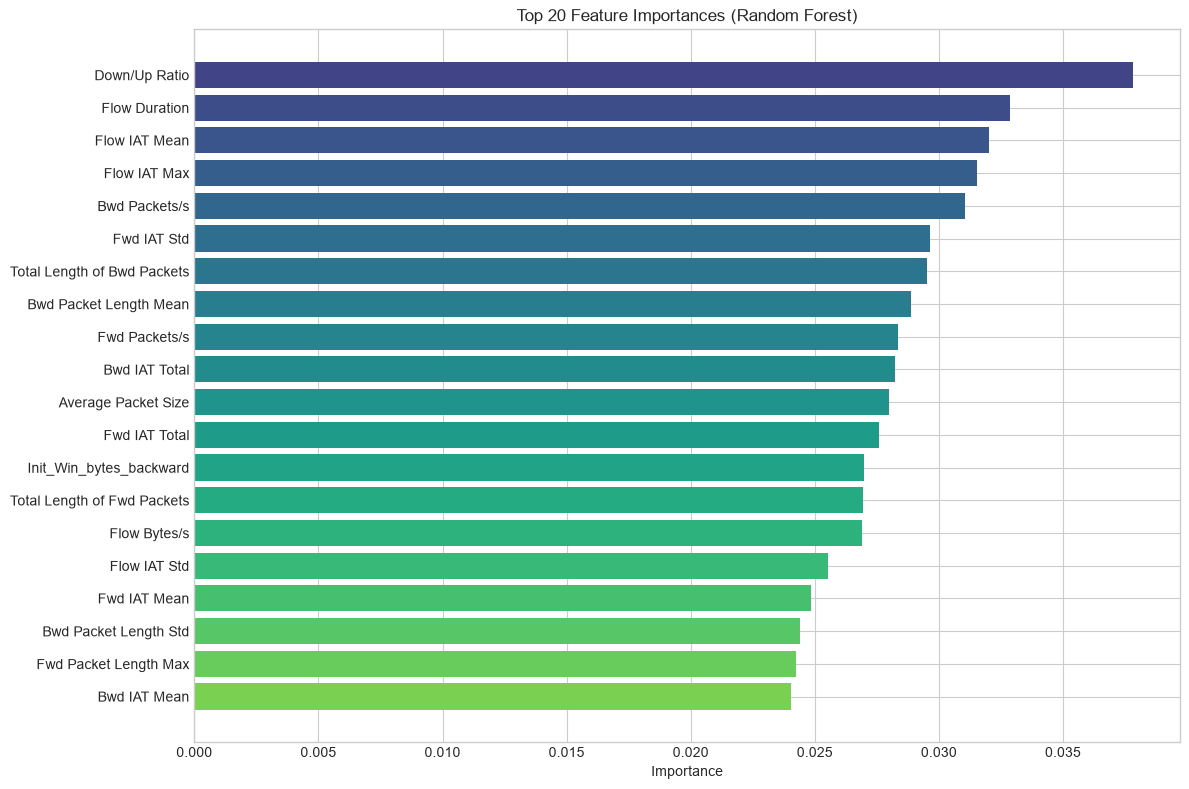

In [10]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Select top features based on importance
TOP_K = 30
selected_features = feature_importance.head(TOP_K)['feature'].tolist()

print(f"\nSelected {TOP_K} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

X_selected = X_numeric[selected_features].copy()


Selected 30 features:
  1. Down/Up Ratio
  2. Flow Duration
  3. Flow IAT Mean
  4. Flow IAT Max
  5. Bwd Packets/s
  6. Fwd IAT Std
  7. Total Length of Bwd Packets
  8. Bwd Packet Length Mean
  9. Fwd Packets/s
  10. Bwd IAT Total
  11. Average Packet Size
  12. Fwd IAT Total
  13. Init_Win_bytes_backward
  14. Total Length of Fwd Packets
  15. Flow Bytes/s
  16. Flow IAT Std
  17. Fwd IAT Mean
  18. Bwd Packet Length Std
  19. Fwd Packet Length Max
  20. Bwd IAT Mean
  21. Flow Packets/s
  22. Packet Length Std
  23. Packet Length Mean
  24. Fwd Packet Length Mean
  25. Bwd Packet Length Min
  26. Bwd Packet Length Max
  27. Flow IAT Min
  28. Packet Length Variance
  29. Bwd IAT Std
  30. Min Packet Length


In [12]:
# Remove highly correlated features
print("\nRemoving highly correlated features (>0.95)...")

corr_matrix = X_selected.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(f"Highly correlated features to remove: {len(to_drop)}")
if to_drop:
    print(f"  {to_drop}")
    X_selected = X_selected.drop(columns=to_drop)

print(f"\nFinal feature count: {X_selected.shape[1]}")


Removing highly correlated features (>0.95)...
Highly correlated features to remove: 0

Final feature count: 30


## 4. Feature Transformation

In [13]:
# Apply log transformation to skewed features
print("Applying log transformation to skewed features...")

skewness = X_selected.skew()
skewed_features = skewness[skewness.abs() > 2].index.tolist()

print(f"Skewed features (|skew| > 2): {len(skewed_features)}")

X_transformed = X_selected.copy()
for col in skewed_features:
    if X_transformed[col].min() >= 0:
        X_transformed[col] = np.log1p(X_transformed[col])

# Compare skewness before and after
print("\nSkewness comparison (sample):")
for col in skewed_features[:5]:
    before = X_selected[col].skew()
    after = X_transformed[col].skew()
    print(f"  {col}: {before:.2f} -> {after:.2f}")

Applying log transformation to skewed features...
Skewed features (|skew| > 2): 10

Skewness comparison (sample):
  Flow IAT Max: 2.01 -> -1.11
  Total Length of Bwd Packets: 2.01 -> -0.91
  Fwd Packets/s: 2.05 -> -0.57
  Bwd IAT Total: 2.01 -> -1.13
  Average Packet Size: 2.08 -> -0.83


In [14]:
# Feature scaling
print("\nApplying StandardScaler...")

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_transformed),
    columns=X_transformed.columns,
    index=X_transformed.index
)

print("\nScaled data statistics:")
print(X_scaled.describe().round(2))


Applying StandardScaler...

Scaled data statistics:
       Down/Up Ratio  Flow Duration  Flow IAT Mean  Flow IAT Max  \
count       20000.00       20000.00       20000.00      20000.00   
mean            0.00          -0.00           0.00          0.00   
std             1.00           1.00           1.00          1.00   
min            -1.74          -1.00          -1.01         -6.83   
25%            -0.87          -0.71          -0.71         -0.52   
50%            -0.00          -0.31          -0.31          0.16   
75%             0.87           0.39           0.39          0.71   
max             1.72           8.51          10.83          2.43   

       Bwd Packets/s  Fwd IAT Std  Total Length of Bwd Packets  \
count       20000.00     20000.00                     20000.00   
mean            0.00         0.00                        -0.00   
std             1.00         1.00                         1.00   
min            -1.00        -1.01                        -4.36   
25% 

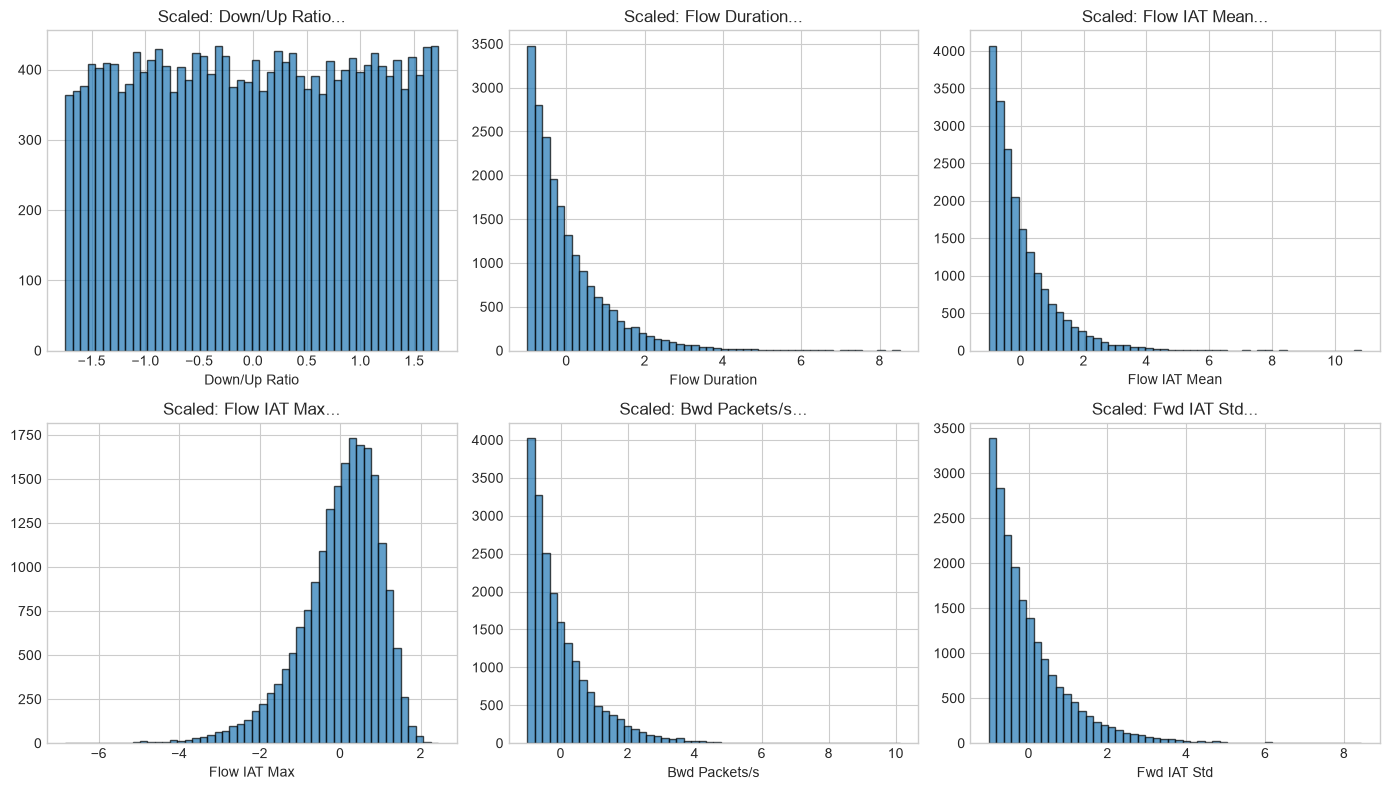

In [15]:
# Visualize scaled distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = X_scaled.columns[:6]
for idx, col in enumerate(sample_cols):
    axes[idx].hist(X_scaled[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col[:30])
    axes[idx].set_title(f'Scaled: {col[:25]}...')

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'scaled_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Handle Class Imbalance

In [16]:
# Analyze class distribution
print("Class distribution:")
class_dist = pd.Series(y).value_counts()
print(class_dist)

# Calculate imbalance ratio
imbalance_ratio = class_dist.max() / class_dist.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")

Class distribution:
Label
BENIGN         14000
DoS Hulk        2000
PortScan        1600
DDoS            1000
Bot              800
Brute Force      600
Name: count, dtype: int64

Imbalance ratio: 23.33x


In [17]:
# Split data before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training set: (16000, 30)
Test set: (4000, 30)

Training class distribution:
Label
BENIGN         11200
DoS Hulk        1600
PortScan        1280
DDoS             800
Bot              640
Brute Force      480
Name: count, dtype: int64


In [18]:
# Apply SMOTE for oversampling minority classes
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    print("Applying SMOTE + Undersampling...")
    
    # Combined approach: oversample minority + undersample majority
    over = SMOTE(sampling_strategy=0.5, random_state=42)
    under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)
    
    steps = [('over', over), ('under', under)]
    pipeline = ImbPipeline(steps=steps)
    
    X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train, y_train)
    
    print(f"\nBalanced training set: {X_train_balanced.shape}")
    print("\nBalanced class distribution:")
    print(pd.Series(y_train_balanced).value_counts())
    
except ImportError:
    print("imbalanced-learn not installed. Using original data.")
    print("Install with: pip install imbalanced-learn")
    X_train_balanced = X_train
    y_train_balanced = y_train

Applying SMOTE + Undersampling...


ValueError: "sampling_strategy" can be a float only when the type of target is binary. For multi-class, use a dict.

NameError: name 'y_train_balanced' is not defined

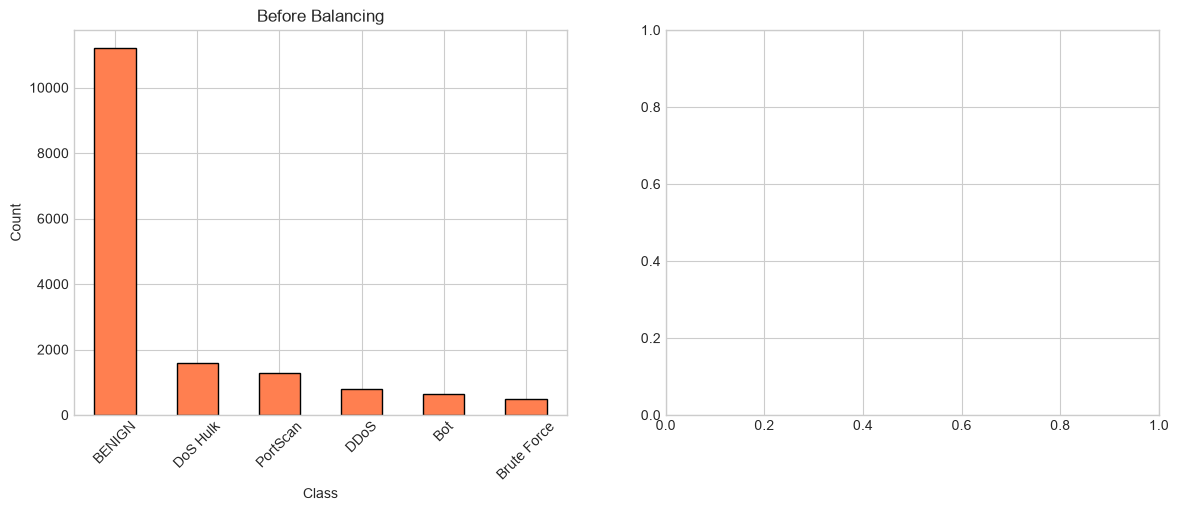

In [19]:
# Visualize class distribution before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Before Balancing')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# After
pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('After Balancing (SMOTE + Undersampling)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Create Additional Features

In [20]:
def create_additional_features(df):
    """
    Create additional engineered features.
    """
    df_new = df.copy()
    
    # Ratio features (if columns exist)
    if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
        df_new['Fwd_Bwd_Packet_Ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)
    
    if 'Total Length of Fwd Packets' in df.columns and 'Total Length of Bwd Packets' in df.columns:
        df_new['Fwd_Bwd_Bytes_Ratio'] = df['Total Length of Fwd Packets'] / (df['Total Length of Bwd Packets'] + 1)
    
    # Flag ratios
    flag_cols = [c for c in df.columns if 'Flag' in c and 'Count' in c]
    if len(flag_cols) >= 2:
        df_new['Flag_Ratio'] = df[flag_cols[0]] / (df[flag_cols[1]] + 1)
    
    # Packet size features
    if 'Packet Length Mean' in df.columns and 'Packet Length Std' in df.columns:
        df_new['Packet_CV'] = df['Packet Length Std'] / (df['Packet Length Mean'] + 1)
    
    return df_new

# Note: Additional features would need to be applied to original data before scaling
print("Additional feature engineering functions defined.")
print("These can be applied during preprocessing pipeline.")

Additional feature engineering functions defined.
These can be applied during preprocessing pipeline.


## 7. Save Processed Data and Artifacts

In [21]:
# Save processed data
print("Saving processed data...")

# Convert to DataFrame if needed
if not isinstance(X_train_balanced, pd.DataFrame):
    X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_scaled.columns)

# Save training data
X_train_balanced.to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
pd.Series(y_train_balanced, name='label').to_csv(PROCESSED_DIR / 'y_train.csv', index=False)

# Save test data
X_test.to_csv(PROCESSED_DIR / 'X_test.csv', index=False)
pd.Series(y_test, name='label').to_csv(PROCESSED_DIR / 'y_test.csv', index=False)

print(f"\n Training data saved: {X_train_balanced.shape}")
print(f" Test data saved: {X_test.shape}")

Saving processed data...


NameError: name 'X_train_balanced' is not defined

In [23]:
# Save preprocessing artifacts
print("\nSaving preprocessing artifacts...")

# Save scaler
joblib.dump(scaler, PROCESSED_DIR / 'scaler.pkl')
print(" Scaler saved")

# Save label encoder
joblib.dump(le, PROCESSED_DIR / 'label_encoder.pkl')
print(" Label encoder saved")

# Save selected features list
with open(PROCESSED_DIR / 'selected_features.txt', 'w') as f:
    f.write('\n'.join(X_scaled.columns))
print(" Selected features list saved")

# Save feature importance
feature_importance.to_csv(PROCESSED_DIR / 'feature_importance.csv', index=False)
print(" Feature importance saved")


Saving preprocessing artifacts...
 Scaler saved
 Label encoder saved
 Selected features list saved
 Feature importance saved


In [24]:
# Summary
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"\n Original features: {X.shape[1]}")
print(f" Selected features: {X_scaled.shape[1]}")
print(f"\n Training samples: {len(X_train_balanced)}")
print(f" Test samples: {len(X_test)}")
print(f"\n Classes: {len(le.classes_)}")
print(f"   {list(le.classes_)}")

print(f"\n Saved files:")
for f in PROCESSED_DIR.glob('*'):
    print(f"   - {f.name}")


FEATURE ENGINEERING SUMMARY

 Original features: 48
 Selected features: 30


NameError: name 'X_train_balanced' is not defined

## Next Steps

Proceed to:
1. **03_model_training.ipynb** (or model_training.ipynb) - Train ML models
2. **04_model_evaluation.ipynb** - Evaluate model performance
3. **05_explainability.ipynb** - SHAP analysis